# 🔄 Customer Churn Predictor

> Predicting whether a customer will churn based on behavioral and demographic features.

## 📁 Dataset
- **Source:** Kaggle `Predict Customer Churn` Competition Dataset
- **Files:** `train.csv`, `test.csv`

## 🎯 Objective
Build a machine learning model that accurately classifies customers as churned or retained and stores that data with the possibility in a different csv,
helping businesses identify at-risk customers before they leave.

## 🔧 Workflow
1. Exploratory Data Analysis (EDA)
2. Data Preprocessing & Feature Engineering
3. Model Building & Evaluation

## Section 1 :- Loading data and preview

In [173]:
import pandas as pd

test_df = pd.read_csv('test.csv')

train_df = pd.read_csv('train.csv')
train_df.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [174]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

## Section 2 :- Data pre-processing

### Boolean Mapping

In [175]:
#Creating the mapping variable

yes_no_mapping = {'Yes':1, 'No':0}

* Encoding Partner

In [176]:
train_df['Partner'] = train_df['Partner'].map(yes_no_mapping)
test_df['Partner'] = test_df['Partner'].map(yes_no_mapping)

* Encoding Dependents 

In [177]:
train_df['Dependents'] = train_df['Dependents'].map(yes_no_mapping)
test_df['Dependents'] = test_df['Dependents'].map(yes_no_mapping)

* Encoding PhoneService

In [178]:
train_df['PhoneService'] = train_df['PhoneService'].map(yes_no_mapping)
test_df['PhoneService'] = test_df['PhoneService'].map(yes_no_mapping)

* Encoding 	PaperlessBilling	

In [179]:
train_df['PaperlessBilling'] = train_df['PaperlessBilling'].map(yes_no_mapping)
test_df['PaperlessBilling'] = test_df['PaperlessBilling'].map(yes_no_mapping)

In [180]:
train_df['Churn'] = train_df['Churn'].map(yes_no_mapping)

### Converting Gender

In [181]:
gender_mapping = {'Female': 1, 'Male': 0}
train_df['gender'] = train_df['gender'].map(gender_mapping)
test_df['gender'] = test_df['gender'].map(gender_mapping)

### Creating Dummies

In [182]:
#Train Data
train_df = pd.get_dummies(train_df, columns=['InternetService'], drop_first=True)
train_df = pd.get_dummies(train_df, columns=['OnlineSecurity'], drop_first=True)
train_df = pd.get_dummies(train_df, columns=['OnlineBackup'], drop_first=True)
train_df = pd.get_dummies(train_df, columns=['MultipleLines'], drop_first=True)
train_df = pd.get_dummies(train_df, columns=['DeviceProtection'], drop_first=True)
train_df = pd.get_dummies(train_df, columns=['TechSupport'], drop_first=True)
train_df = pd.get_dummies(train_df, columns=['StreamingTV'], drop_first=True)
train_df = pd.get_dummies(train_df, columns=['StreamingMovies'], drop_first=True)
train_df = pd.get_dummies(train_df, columns=['PaymentMethod'], drop_first=True)
train_df = pd.get_dummies(train_df, columns=['Contract'], drop_first=True)

#Test Data
test_df = pd.get_dummies(test_df, columns=['InternetService'], drop_first=True)
test_df = pd.get_dummies(test_df, columns=['OnlineSecurity'], drop_first=True)
test_df = pd.get_dummies(test_df, columns=['OnlineBackup'], drop_first=True)
test_df = pd.get_dummies(test_df, columns=['MultipleLines'], drop_first=True)
test_df = pd.get_dummies(test_df, columns=['DeviceProtection'], drop_first=True)
test_df = pd.get_dummies(test_df, columns=['TechSupport'], drop_first=True)
test_df = pd.get_dummies(test_df, columns=['StreamingTV'], drop_first=True)
test_df = pd.get_dummies(test_df, columns=['StreamingMovies'], drop_first=True)
test_df = pd.get_dummies(test_df, columns=['PaymentMethod'], drop_first=True)
test_df = pd.get_dummies(test_df, columns=['Contract'], drop_first=True)


In [183]:
bool_cols = train_df.select_dtypes(include='bool').columns
train_df[bool_cols] = train_df[bool_cols].astype(int)

bool_cols = test_df.select_dtypes(include='bool').columns
test_df[bool_cols] = test_df[bool_cols].astype(int)

## Section 3 :- Checking Correlation

In [184]:
train_df.corr()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Contract_One year,Contract_Two year
id,1.000000,0.001305,0.002035,0.008876,0.004912,0.019322,-0.001100,-0.000988,0.005729,0.014331,...,0.008089,-0.000395,0.007897,-0.000395,0.008341,0.006767,-0.005273,-0.006690,0.008106,0.006852
gender,0.001305,1.000000,-0.000103,0.003706,-0.000144,-0.001504,0.007558,0.005776,0.013647,0.006192,...,0.008341,-0.006382,0.009690,-0.006382,0.009065,0.002992,0.001899,-0.009037,-0.005010,0.002234
SeniorCitizen,0.002035,-0.000103,1.000000,-0.026468,-0.215769,-0.084291,0.032778,0.199061,0.229079,0.042786,...,-0.081487,-0.183106,0.132319,-0.183106,0.131289,-0.074079,0.248801,-0.156920,-0.065821,-0.161808
Partner,0.008876,0.003706,-0.026468,1.000000,0.532824,0.476774,0.029167,-0.082652,0.045082,0.371255,...,0.187459,0.077198,0.121641,0.077198,0.122415,0.165327,-0.214568,-0.064652,0.070747,0.362867
Dependents,0.004912,-0.000144,-0.215769,0.532824,1.000000,0.257342,-0.004184,-0.211968,-0.203674,0.077273,...,0.080867,0.239590,-0.076717,0.239590,-0.076504,0.109720,-0.266731,0.114427,0.059168,0.304545
tenure,0.019322,-0.001504,-0.084291,0.476774,0.257342,1.000000,0.030192,-0.113104,0.124043,0.769703,...,0.376805,0.098295,0.259955,0.098295,0.260962,0.325279,-0.382261,-0.179806,0.153601,0.654117
PhoneService,-0.001100,0.007558,0.032778,0.029167,-0.004184,0.030192,1.000000,0.022072,0.193100,0.090759,...,-0.098914,0.141986,-0.003770,0.141986,-0.006496,-0.006455,0.022989,-0.023107,-0.014462,0.028977
PaperlessBilling,-0.000988,0.005776,0.199061,-0.082652,-0.211968,-0.113104,0.022072,1.000000,0.491644,0.176907,...,0.041379,-0.465552,0.298722,-0.465552,0.299296,-0.064289,0.356043,-0.300470,-0.073920,-0.259718
MonthlyCharges,0.005729,0.013647,0.229079,0.045082,-0.203674,0.124043,0.193100,0.491644,1.000000,0.634237,...,0.347226,-0.806062,0.691321,-0.806062,0.690451,0.009551,0.374051,-0.463837,-0.032513,-0.161183
TotalCharges,0.014331,0.006192,0.042786,0.371255,0.077273,0.769703,0.090759,0.176907,0.634237,1.000000,...,0.520876,-0.382495,0.576933,-0.382495,0.577374,0.242729,-0.129489,-0.317185,0.139012,0.363924


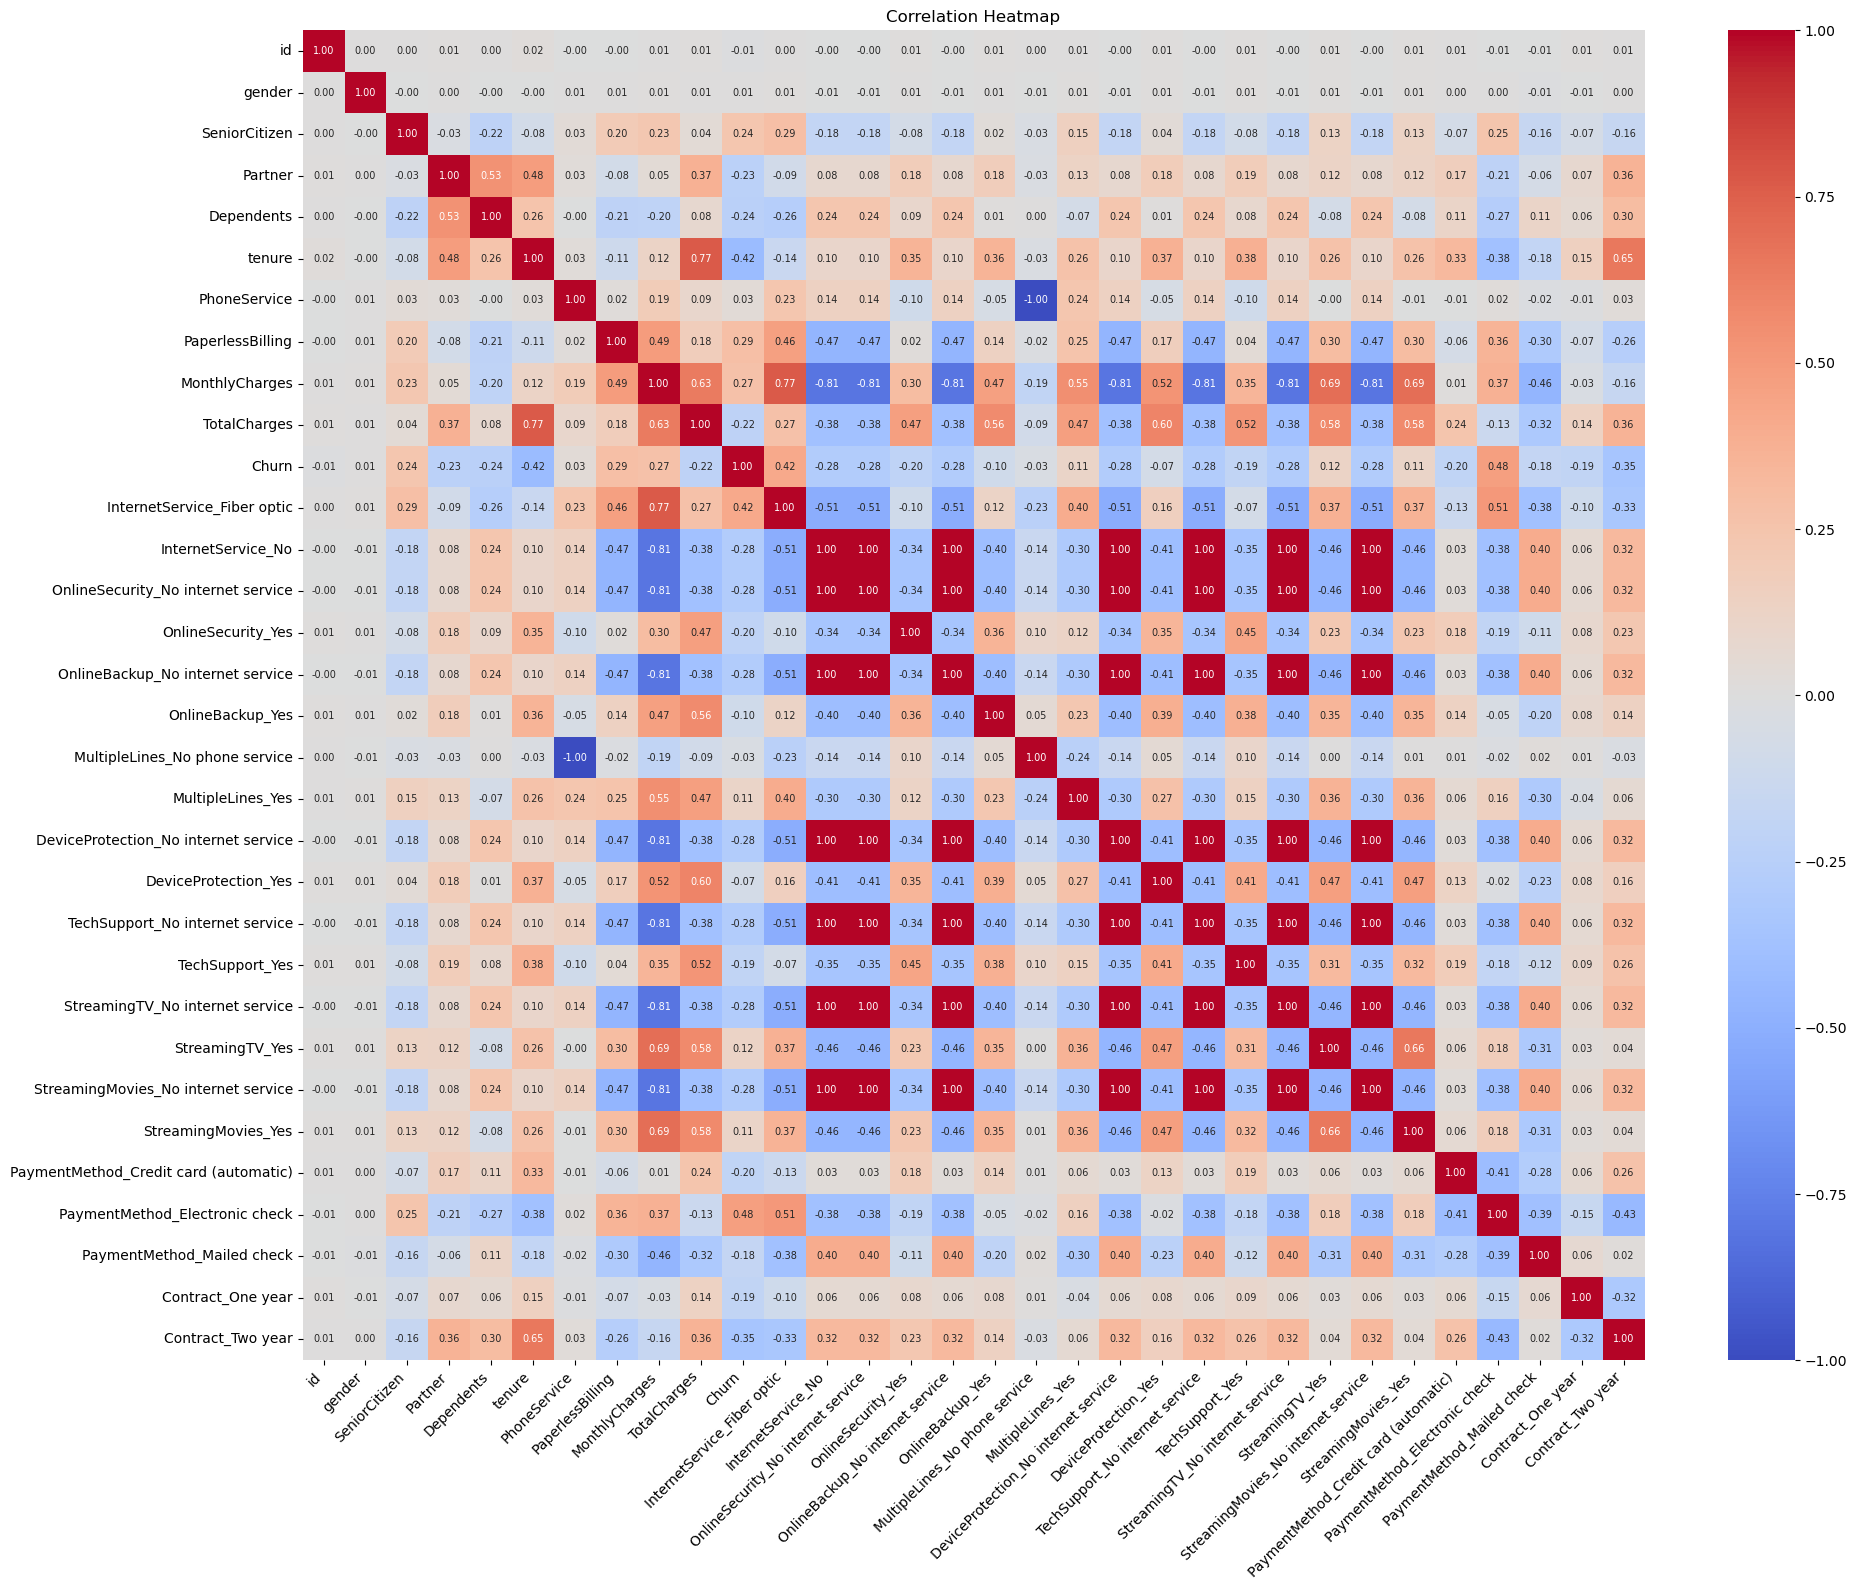

In [185]:
#correlation heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 16))
sns.heatmap(train_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', 
            annot_kws={'size': 7})
plt.title('Correlation Heatmap')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [186]:
#Checking Correlation with churn
train_df.corrwith(train_df['Churn']).sort_values(ascending=False)

Churn                                    1.000000
PaymentMethod_Electronic check           0.476255
InternetService_Fiber optic              0.418819
PaperlessBilling                         0.285107
MonthlyCharges                           0.272997
SeniorCitizen                            0.236362
StreamingTV_Yes                          0.117280
MultipleLines_Yes                        0.114951
StreamingMovies_Yes                      0.114589
PhoneService                             0.034843
gender                                   0.006808
id                                      -0.012971
MultipleLines_No phone service          -0.034843
DeviceProtection_Yes                    -0.074228
OnlineBackup_Yes                        -0.100109
PaymentMethod_Mailed check              -0.178668
Contract_One year                       -0.189436
TechSupport_Yes                         -0.191011
PaymentMethod_Credit card (automatic)   -0.201075
OnlineSecurity_Yes                      -0.204544


## Section 4 :- Training the Model

### Making the features and target

In [190]:
from sklearn.model_selection import train_test_split

features = train_df.drop(columns=['Churn', 'gender', 'id'])
target = train_df['Churn']

features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.2, random_state=27)

### Building and fitting the model

In [201]:
from sklearn.linear_model import LogisticRegression

churn_model = LogisticRegression(max_iter=5000, random_state=27, class_weight='balanced')
churn_model.fit(features_train, target_train)

LogisticRegression(class_weight='balanced', max_iter=5000, random_state=27)

## Section 5 :- Testing the Model

In [202]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

target_pred = churn_model.predict(features_test)

print("Accuracy:", accuracy_score(target_test, target_pred))
print("Confusion Matrix:\n", confusion_matrix(target_test, target_pred))
print("Report:\n", classification_report(target_test, target_pred))

Accuracy: 0.8067974318195206
Confusion Matrix:
 [[72386 19698]
 [ 3262 23493]]
Report:
               precision    recall  f1-score   support

           0       0.96      0.79      0.86     92084
           1       0.54      0.88      0.67     26755

    accuracy                           0.81    118839
   macro avg       0.75      0.83      0.77    118839
weighted avg       0.86      0.81      0.82    118839



## Section 6 :- Using XGBoost

In [209]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42, n_jobs=-1, scale_pos_weight=3, eval_metric='logloss')
xgb_model.fit(features_train, target_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=-1,
              num_parallel_tree=None, ...)

In [211]:
target_pred = xgb_model.predict(features_test)

print("Accuracy:", accuracy_score(target_test, target_pred))
print("Confusion Matrix:\n", confusion_matrix(target_test, target_pred))
print("Report:\n", classification_report(target_test, target_pred))

Accuracy: 0.8277753935997442
Confusion Matrix:
 [[75452 16632]
 [ 3835 22920]]
Report:
               precision    recall  f1-score   support

           0       0.95      0.82      0.88     92084
           1       0.58      0.86      0.69     26755

    accuracy                           0.83    118839
   macro avg       0.77      0.84      0.79    118839
weighted avg       0.87      0.83      0.84    118839



### It is clear that XGBoost has a better overall performance hence XGBoost will be used to check `test.csv` 

## Section 7 :- Finding Churns for `test.csv`

### Making the XGBoost Model on the whole train data

In [212]:
xgb_model = XGBClassifier(random_state=42, n_jobs=-1, scale_pos_weight=3, eval_metric='logloss')
xgb_model.fit(features, target)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=-1,
              num_parallel_tree=None, ...)

### Making test_features

In [213]:
test_features = test_df.drop(columns=['id', 'gender'])

### Making Predictions and Saving it in `submission.csv`

In [214]:
test_predictions = xgb_model.predict(test_features)

submission = pd.DataFrame({
    'id': test_df['id'],
    'Churn': test_predictions
})

submission.to_csv('submission.csv', index=False)